C:\Users\Windows 10\AppData\Local\Temp\ipykernel_7700\3389681780.py:99: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  data['position'] = data['signal'].replace(to_replace=0, method='ffill')


Período In-Sample: 2020-01-02 to 2020-01-02
Período Out-Sample: 2022-01-03 to 2022-01-03


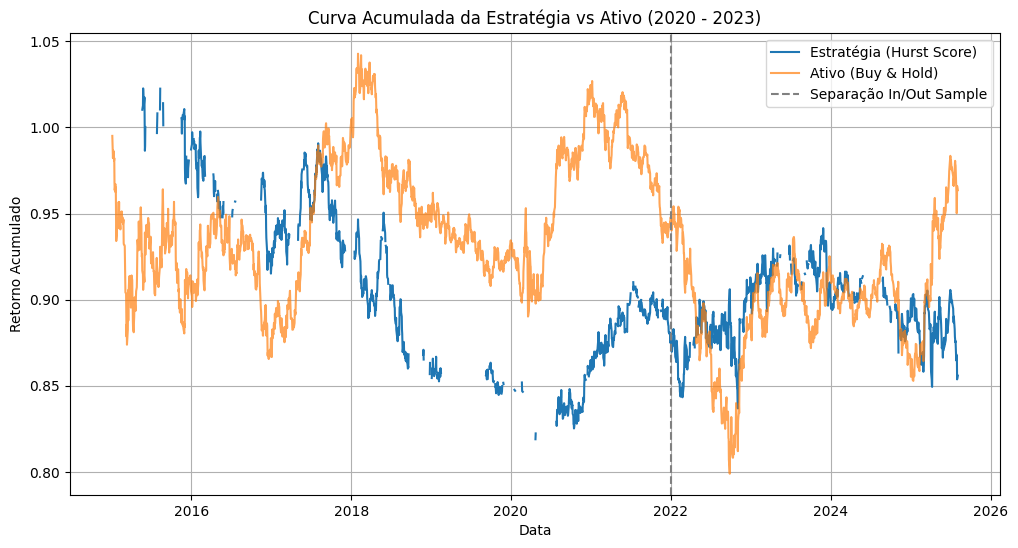

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import MetaTrader5 as mt5
from hurst import compute_Hc


login = 14521214
senha = 'Salmos20@@'
servidor = 'CFI2-Real'

if not mt5.initialize():
    print(f"Didn't inicialize")
else:
    if not mt5.login(login, password=senha, server = servidor):
        print(f"Error with the credencials")


symbol = "EURUSD"
selected = mt5.symbol_select(symbol, True)

# To set the period: from 2020-01-01 to 2023-12-31

start = datetime.datetime(2015,1, 1)
end = datetime.datetime(2025, 8, 4)

# To Download the daily data
rates = mt5.copy_rates_range(symbol, mt5.TIMEFRAME_D1, start, end)
mt5.shutdown()

# Converting the data to DataFrame and to format the column of time

data = pd.DataFrame(rates)
data['time'] = pd.to_datetime(data['time'], unit='s')
data.set_index('time', inplace=True)
data = data[['close']]
data.rename(columns={'close':'price'}, inplace=True)
data.dropna(inplace=True)
data.head()


# 3 Block: To set functions for to calculate the RSI e o exponent of Hurst

def rsi(series, period=14):
    
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = delta.clip(upper=0)
    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean()
    rs = avg_gain / avg_loss
    rsi_val = 100 - (100 / (1 + rs))
    return rsi_val

def compute_hurst(ts):
    '''
    It calculates the exponent of Hurxst by using the compute_Hc funtion from Hurst library 
    '''
    H, c, _ = compute_Hc(ts, kind = 'price', simplified=True)
    return H
# 4 Block: To calculate the indicators (RSI and Hurst) and to generate the signals with the new run

# It calculates the RSI with this period
data['RSI'] = rsi(data['price'], period=14)

# The safe function to calculate the exponent of Hurst by using the Hurst library

def safe_compute_hurst(x):
    # If the window has fewer than 100 points, it returns NaN
    if len(x) < 100:
        return np.nan
    return compute_hurst(x)

# To set the window for the calculation of Hurst in 100 periods
window_hurst = 100
data['Hurst'] = data['price'].rolling(window=window_hurst, min_periods=window_hurst)\
    .apply(safe_compute_hurst, raw=False)


# Function to generate trading sinals;
# Operamos somente se HUrst > 0.50;
#Se operamos, o RSI define a direção;
# - Se RSI > 50, sinal de compra (1);
# - Se RSI < 50, sinal de venda (-1);
# - Caso contrário, sinal zero.
def signal_generator(row):
    if row['Hurst'] > 0.5:
        if row['RSI'] > 50:
            return 1
        elif row['RSI'] < 50:
            return -1
        else:
            return 0
        
data['signal'] = data.apply(signal_generator, axis=1)

# It propagates the signal to keep the position until a new signal is generated
data['position'] = data['signal'].replace(to_replace=0, method='ffill')


data.head(15)
# 5 Block: Separar os dados em in-sample e out-of-sample

in_sample = data.loc['2020-01-01' : '2021-12-31'].copy()
out_sample = data.loc['2022-01-01' : '2023-12-31'].copy()

print('Período In-Sample:', in_sample.index[0].date(), 'to', in_sample.index[0].date())
print('Período Out-Sample:', out_sample.index[0].date(), 'to', out_sample.index[0].date())
# 6 Block: Backtesting - Calculation of daily returns of the strategy

# It calculates the daily returns of asset
data['ret_asset'] = np.log(data['price'] / data['price'].shift(1))

# Returns of the strategy: position of the previous day * return of assert
data['ret_strategy']= data['position'].shift(1) * data['ret_asset']

# It calculates the accumulated (exponentia of sum of log returns)
data['cum_ret_asset'] = data['ret_asset'].cumsum().apply(np.exp)
data['cum_ret_strategy'] = data['ret_strategy'].cumsum().apply(np.exp)

data[['cum_ret_asset', 'cum_ret_strategy']].dropna().head()
plt.figure(figsize=(12,6))
plt.plot(data.index, data['cum_ret_strategy'], label='Estratégia (Hurst Score)')
plt.plot(data.index, data['cum_ret_asset'], label='Ativo (Buy & Hold)', alpha=0.7)
plt.axvline(x=datetime.datetime(2022, 1, 1), color ='gray', linestyle = '--', label='Separação In/Out Sample')
plt.title('Curva Acumulada da Estratégia vs Ativo (2020 - 2023)')
plt.xlabel('Data')
plt.ylabel('Retorno Acumulado')
plt.legend()
plt.grid(True)
plt.show()



Drawdown


Média do Drawdown: -11.81
Mediana do Drawdown: -12.32
Moda do Drawdown: 0.00
Máxima do Drawdown: -20.17


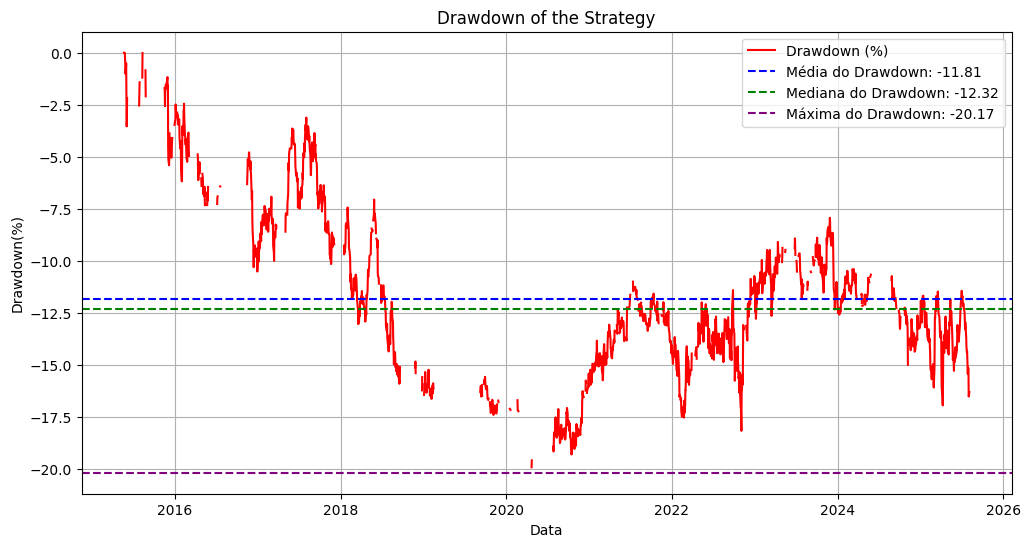

In [54]:
# It calculates the running max of accumulated curve of the strategy
data['running_max'] = data['cum_ret_strategy'].cummax()

# It calculates the drawdown
data['drawdown'] = (data['cum_ret_strategy'] / data['running_max'] - 1 ) *100

# Calculations of statistics

mean_dd = data['drawdown'].mean()
median_dd = data['drawdown'].median()
mode_dd_series= data['drawdown'].mode()
mode_dd = mode_dd_series.iloc[0] if not mode_dd_series.empty else np.nan
max_dd = data['drawdown'].min()

# To display these statistics
print(f'Média do Drawdown: {mean_dd:.2f}')
print(f'Mediana do Drawdown: {median_dd:.2f}')
print(f'Moda do Drawdown: {mode_dd:.2f}')
print(f'Máxima do Drawdown: {max_dd:.2f}')

# Plot of the Drawdown with the statistics
plt.figure(figsize=(12,6))
plt.plot(data.index, data.drawdown, label='Drawdown (%)', color='r')
plt.axhline(mean_dd, color='b', linestyle='--', label =f'Média do Drawdown: {mean_dd:.2f}')
plt.axhline(median_dd, color='g', linestyle='--', label =f'Mediana do Drawdown: {median_dd:.2f}')
plt.axhline(max_dd, color='purple', linestyle='--', label =f'Máxima do Drawdown: {max_dd:.2f}')
plt.title('Drawdown of the Strategy')
plt.xlabel('Data')
plt.ylabel('Drawdown(%)')
plt.legend()
plt.grid(True)
plt.show()


Sharp


Média do Sharpe: -1.45
Mediana do Sharpe: -1.41
Moda do Sharpe: -3.30
Máximo do Sharpe: 0.02
Mínimo do Sharpe: -3.30


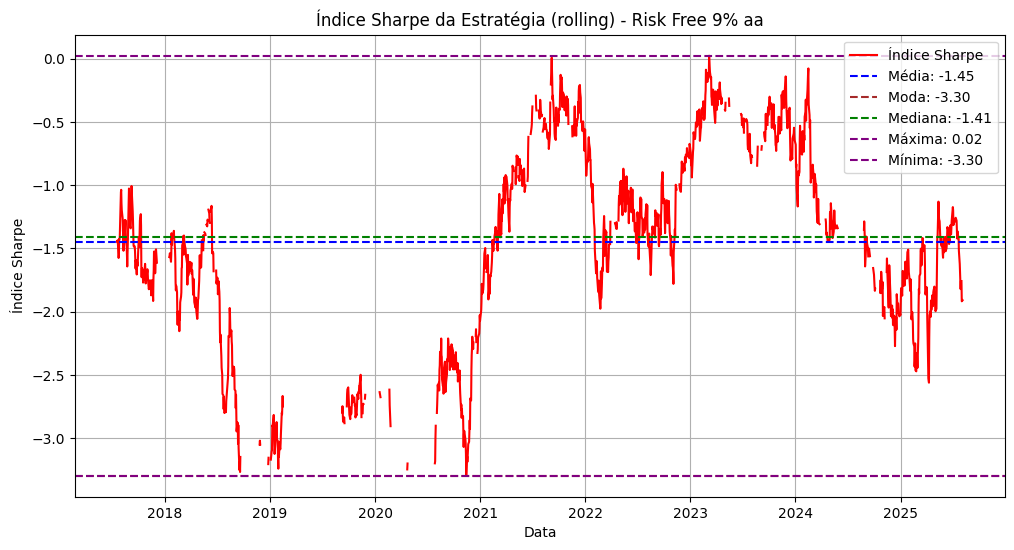

In [55]:
rolling_window = 252 # window by year (often, 252 is used because the Sharp ratio is measured on an annual basis)

# Risk free rate annual
risk_free_annual = 0.09 # como se fosse o juros (porcentagem livre de risco annual)

# Converting the risk free to daily (divided into)
risk_free_daily = risk_free_annual / 252

# Function to calculate the Sharpe ration for a window of returns (with risk free rate)
def rolling_sharpe (x):
    # It calculates the surplus returns (asset return - risk free daily)
    excess_returns = x - risk_free_daily  # x is a 252-day window of strategy returns
    std_excess = np.std(excess_returns)
    if std_excess == 0:
        return np.nan
    return np.sqrt(252) * np.mean(excess_returns) / std_excess

# To calculate the Sharpe ratio rolling using the strategy returns
data['rolling_sharpe'] = data['ret_strategy'].dropna().rolling(window=rolling_window, min_periods=rolling_window)\
    .apply(rolling_sharpe, raw=True)

# To calculate the statistics of rolling Sharpe' Index
mean_sharpe = data["rolling_sharpe"].mean()
median_sharpe = data["rolling_sharpe"].median()
mode_sharpe_series = data["rolling_sharpe"].mode()
mode_sharpe = mode_sharpe_series.iloc[0] if not mode_sharpe_series.empty else np.nan
max_sharpe = data["rolling_sharpe"].max()
min_sharpe = data["rolling_sharpe"].min()

# To display these statistics
print(f'Média do Sharpe: {mean_sharpe:.2f}')
print(f'Mediana do Sharpe: {median_sharpe:.2f}')
print(f'Moda do Sharpe: {mode_sharpe:.2f}')
print(f'Máximo do Sharpe: {max_sharpe:.2f}')
print(f'Mínimo do Sharpe: {min_sharpe:.2f}')

# Plot

plt.figure(figsize=(12,6))
plt.plot(data.index, data['rolling_sharpe'], label='Índice Sharpe', color='r')
plt.axhline(mean_sharpe, color='b', linestyle='--', label =f'Média: {mean_sharpe:.2f}')
plt.axhline(mode_sharpe, color='brown', linestyle='--', label =f'Moda: {mode_sharpe:.2f}')
plt.axhline(median_sharpe, color='g', linestyle='--', label =f'Mediana: {median_sharpe:.2f}')
plt.axhline(max_sharpe, color='purple', linestyle='--', label =f'Máxima: {max_sharpe:.2f}')
plt.axhline(min_sharpe, color='purple', linestyle='--', label =f'Mínima: {min_sharpe:.2f}')
plt.title('Índice Sharpe da Estratégia (rolling) - Risk Free 9% aa')
plt.xlabel('Data')
plt.ylabel('Índice Sharpe')
plt.legend()
plt.grid(True)
plt.show()


Quarteto
 - Beta
 - Assertividade
 - Payoff
 - Expectancy of returns per trade

In [56]:
# Beta ↓

# Calculando novamente, apenas parar ratificar

data['excess_ret_strategy'] = data['ret_strategy'] - risk_free_daily
data['excess_ret_asset'] = data['ret_asset'] - risk_free_daily

# Romving the NaN's for to the regression
reg_data = data.dropna(subset=['excess_ret_strategy', 'ret_asset'])

# Regressão Linear; excess_ret_strategy = alpha + beta * excess_ret_strateg
# We using np.polyfit to get beta (inclination) and alpha (intercept)
beta, alpha_daily = np.polyfit(reg_data['excess_ret_asset'], reg_data['excess_ret_strategy'], 1)

print(f'Beta da Estratégia: {beta:.4f}')
print('Beta da Estratégia: {:.4f}'.format(beta))

Beta da Estratégia: 0.0481
Beta da Estratégia: 0.0481


In [57]:
# Assertiviness ↓

# It identifies trading's changes: when the position changes (open and close)
data['trade_change'] = data['position'].diff().fillna(0).abs() > 0

# It creates an identifier of trades (cumulative always thare is change)
data['trade_id'] = data['trade_change'].cumsum()

# Its only filters the periods in which the strategy is trading (non-zero position)
trades = data[data['position'] != 0].groupby('trade_id').agg({
    'ret_strategy' : lambda x: np.prod(1 + x) - 1, # Retorno acumulado do trade
    'signal':'first'
})

# Taxa de acertos
hit_trade = (trades['ret_strategy'] >0).mean()

print(f'The Hit Rate (Win Rate) of this model is: {hit_trade:.2%}.')

The Hit Rate (Win Rate) of this model is: 35.32%.


In [58]:
# Payoff ↓

# Select the winers and losers trades

win_trades = trades[trades['ret_strategy'] > 0]
loss_trades = trades[trades['ret_strategy'] < 0]

# Calculates the average  profit of winers trades
avg_win = win_trades['ret_strategy'].mean()

# Calculates the average absolut profit of losers trades
avg_loss = abs(loss_trades['ret_strategy']).mean()

# Calculates the Payoff Ratio
payoff_ratio = avg_win / avg_loss if avg_loss != 0 else np.nan

print('Ganho médio dos trades vencedores: {:.2%}.'.format(avg_win))
print('Ganho médio dos trades perdedores: {:.2%}.'.format(avg_loss))
print(f'Payoff Ratio: {payoff_ratio:.4f}')

Ganho médio dos trades vencedores: 1.04%.
Ganho médio dos trades perdedores: 0.69%.
Payoff Ratio: 1.5031


In [60]:
# Expectancy ↓

win_rate = hit_trade
loss_rate = 1-win_rate

# Expectation (the same meaning) =  (win probability * average profit) - (loss probability * mean loss)
expectancy = (win_rate * avg_win) - (loss_rate * avg_loss)
print('Expectancy per trade: {:.2%}.'.format(expectancy))

Expectancy per trade: -0.08%.


In [19]:
symbol_map = {
    "XAUUSD": "XAUUSD_",
    "EURUSD": "EURUSD_",
}

def get_mt5_symbol(api_symbol):
    return symbol_map.get(api_symbol, api_symbol)

In [21]:
get_mt5_symbol("XAUUSD_")

'XAUUSD_'